# CNN - Cats vs Dogs

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score


# 1- Dataset Download - Kaggle API

In [2]:
!pip install kagglehub

In [3]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


# معرفة شكل الفلودرات واكتشاف هيكل البيانات

In [4]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    break


/kaggle/input/microsoft-catsvsdogs-dataset


نتأكد وش داخل المسار الرئيسي :

In [5]:
import os

base_path = "/kaggle/input/microsoft-catsvsdogs-dataset"
print(os.listdir(base_path))


['PetImages', 'readme[1].txt', 'MSR-LA - 3467.docx']


نحتاج منه PetImages

In [6]:
dataset_path = os.path.join(base_path, "PetImages")
print(os.listdir(dataset_path))


['Dog', 'Cat']


نتأكد من عدد الصور

In [7]:
cat_dir = os.path.join(dataset_path, "Cat")
dog_dir = os.path.join(dataset_path, "Dog")

print("Number of cat images:", len(os.listdir(cat_dir)))
print("Number of dog images:", len(os.listdir(dog_dir)))


Number of cat images: 12501
Number of dog images: 12501


# 2- Clean Data

تحديد مسار البيانات

In [8]:
import os

base_path = "/kaggle/input/microsoft-catsvsdogs-dataset/PetImages"
cat_dir = os.path.join(base_path, "Cat")
dog_dir = os.path.join(base_path, "Dog")

print("Cat folder:", cat_dir)
print("Dog folder:", dog_dir)


Cat folder: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Cat
Dog folder: /kaggle/input/microsoft-catsvsdogs-dataset/PetImages/Dog


check and clean images

فحص الصور وتضمين الصور السليمة في فولدر لحالها  

In [9]:
from PIL import Image

def get_valid_images(folder):
    valid_images = []
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)
        try:
            img = Image.open(file_path)
            img.verify()
            valid_images.append(filename)
        except:
            pass
    return valid_images

cat_images = get_valid_images(cat_dir)
dog_images = get_valid_images(dog_dir)

print("Valid cat images:", len(cat_images))
print("Valid dog images:", len(dog_images))


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Valid cat images: 12499
Valid dog images: 12499


نخلط البيانات عشان يتعلم المودل من بيانات متنوعة وما يصير اوفر فيتتنق

In [10]:
import random

random.seed(42)

random.shuffle(cat_images)
random.shuffle(dog_images)


# 3- Train and Test Data split

70% Train

15% Validation

15% Test

ليه validation؟

لأننا نحتاج أثناء التدريب نراقب أداء المودل على بيانات ما شافها أثناء التعلم.

In [13]:
def split_data(images, train_ratio=0.7, val_ratio=0.15):
    total = len(images)
    train_end = int(total * train_ratio)
    val_end = int(total * (train_ratio + val_ratio))

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    return train_images, val_images, test_images

cat_train, cat_val, cat_test = split_data(cat_images)
dog_train, dog_val, dog_test = split_data(dog_images)

print("Cats - Train:", len(cat_train), "Validation:", len(cat_val), "Test:", len(cat_test))
print("Dogs - Train:", len(dog_train), "Validation:", len(dog_val), "Test:", len(dog_test))

Cats - Train: 8749 Validation: 1875 Test: 1875
Dogs - Train: 8749 Validation: 1875 Test: 1875


Create Folders of data split

create folders in /content/cats_dogs_split

the folders now is empty

In [14]:
import os

base_split_dir = "/content/cats_dogs_split"

train_cats_dir = os.path.join(base_split_dir, "train", "cats")
train_dogs_dir = os.path.join(base_split_dir, "train", "dogs")
val_cats_dir = os.path.join(base_split_dir, "validation", "cats")
val_dogs_dir = os.path.join(base_split_dir, "validation", "dogs")
test_cats_dir = os.path.join(base_split_dir, "test", "cats")
test_dogs_dir = os.path.join(base_split_dir, "test", "dogs")

os.makedirs(train_cats_dir, exist_ok=True)
os.makedirs(train_dogs_dir, exist_ok=True)
os.makedirs(val_cats_dir, exist_ok=True)
os.makedirs(val_dogs_dir, exist_ok=True)
os.makedirs(test_cats_dir, exist_ok=True)
os.makedirs(test_dogs_dir, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [15]:
os.listdir("/content")

['.config', 'cats_dogs_split', 'sample_data']

In [16]:
import os

base_split_dir = "/content/cats_dogs_split"

for root, dirs, files in os.walk(base_split_dir):
    print(root)

/content/cats_dogs_split
/content/cats_dogs_split/validation
/content/cats_dogs_split/validation/cats
/content/cats_dogs_split/validation/dogs
/content/cats_dogs_split/test
/content/cats_dogs_split/test/cats
/content/cats_dogs_split/test/dogs
/content/cats_dogs_split/train
/content/cats_dogs_split/train/cats
/content/cats_dogs_split/train/dogs


fill the folders with the images

using flow_from_directory

* train/

  cats/  -> صور قطط للتدريب

  dogs/  -> صور كلاب للتدريب

* validation/

  cats/  -> صور قطط للتحقق

  dogs/  -> صور كلاب للتحقق

* test/

  cats/  -> صور قطط للاختبار

  dogs/  -> صور كلاب للاختبار

In [17]:
import shutil

def copy_images(image_list, source_folder, destination_folder):
    for filename in image_list:
        src = os.path.join(source_folder, filename)
        dst = os.path.join(destination_folder, filename)
        shutil.copy(src, dst)

# Copy cat images
copy_images(cat_train, cat_dir, train_cats_dir)
copy_images(cat_val, cat_dir, val_cats_dir)
copy_images(cat_test, cat_dir, test_cats_dir)

# Copy dog images
copy_images(dog_train, dog_dir, train_dogs_dir)
copy_images(dog_val, dog_dir, val_dogs_dir)
copy_images(dog_test, dog_dir, test_dogs_dir)

print("Images copied successfully.")

Images copied successfully.


In [18]:
print("Train cats:", len(os.listdir(train_cats_dir)))
print("Train dogs:", len(os.listdir(train_dogs_dir)))

print("Validation cats:", len(os.listdir(val_cats_dir)))
print("Validation dogs:", len(os.listdir(val_dogs_dir)))

print("Test cats:", len(os.listdir(test_cats_dir)))
print("Test dogs:", len(os.listdir(test_dogs_dir)))

Train cats: 8749
Train dogs: 8749
Validation cats: 1875
Validation dogs: 1875
Test cats: 1875
Test dogs: 1875


# 4-Data Preprocessing / prepration and Image Data Generators

**Normalization / Rescaling**

change pixel from 0->255  to 0->1  and this better for CNN work

using ImageDataGenerator, it is tool in keras :

1- Read images from the folders

2- Convert them into batches

3- Resize the images

4- Normalize the pixel values

5- Send them to the model during training

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators created successfully.")

ImageDataGenerators created successfully.


To modify the accuricy :

In [ ]:
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=30,
#     zoom_range=0.2,
#     horizontal_flip=True,
#     width_shift_range=0.1,
#     height_shift_range=0.1
# )

# validation_datagen = ImageDataGenerator(rescale=1./255)

# test_datagen = ImageDataGenerator(rescale=1./255)

Creating Training, Validation, and Test Generators

We need to convert the images into something called a Data Generator.

It is an object that performs the following tasks:

1- Reads images from the folder

2- Resizes the images

3-Normalizes the pixel values

4-Creates batches

5- Provides the images along with their labels to the model

In [20]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_split_dir, "train"),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    os.path.join(base_split_dir, "validation"),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(base_split_dir, "test"),
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 17498 images belonging to 2 classes.
Found 3750 images belonging to 2 classes.
Found 3750 images belonging to 2 classes.


# 5- Building the CNN Model

This means we define:

* How many convolution layers

* How many pooling layers

* How many dense layers

* What activation functions to use

* What the output shape will be

Conv2D + MaxPooling are repeated multiple times so the model can learn:

* edges

* textures

* shapes

Flatten
* Used to convert the feature maps into a vector.

Dense
* Used for the final decision making.

Dropout
* Used to reduce overfitting.

Sigmoid output
* Used because the task is a binary classification problem.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

print("CNN model created successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN model created successfully.


To Increase the accuricy:

In [ ]:
# model = Sequential([

#     Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
#     MaxPooling2D((2,2)),

#     Conv2D(64, (3,3), activation='relu'),
#     MaxPooling2D((2,2)),

#     Conv2D(128, (3,3), activation='relu'),
#     MaxPooling2D((2,2)),

#     # Adding New Layer
#     Conv2D(256, (3,3), activation='relu'),
#     MaxPooling2D((2,2)),

#     Flatten(),

#     Dense(128, activation='relu'),
#     Dropout(0.5),

#     Dense(1, activation='sigmoid')
# ])

Model Summary and Compilation

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Compile

In [24]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


# 6- Training the CNN Model

During training:

In each epoch, the following happens:

* A batch of images is taken from the train_generator
* A forward pass is performed
The loss is calculated
* Backpropagation is applied
The weights are updated using Adam

* After the epoch ends, the model evaluates performance on the validation_generator.

In [25]:
# history = model.fit(
#     train_generator,
#     validation_data=validation_generator,
#     epochs=10
# )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 133s 231ms/step - accuracy: 0.5823 - loss: 0.6819 - val_accuracy: 0.7165 - val_loss: 0.5501
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 119s 217ms/step - accuracy: 0.7089 - loss: 0.5661 - val_accuracy: 0.7693 - val_loss: 0.4648
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 117s 214ms/step - accuracy: 0.7477 - loss: 0.5115 - val_accuracy: 0.7936 - val_loss: 0.4408
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 116s 211ms/step - accuracy: 0.7783 - loss: 0.4711 - val_accuracy: 0.8165 - val_loss: 0.4203
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 115s 210ms/step - accuracy: 0.8027 - loss: 0.4341 - val_accuracy: 0.8317 - val_loss: 0.3721
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 119s 217ms/step - accuracy: 0.8167 - loss: 0.4052 - val_accuracy: 0.7856 - val_loss: 0.4583
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 117s 214ms/step - accuracy: 0.8240 - loss: 0.3933 - val_accuracy: 0.8341 - val_loss: 0.3578
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 120s 220ms/step - accuracy: 0.8428 -

To increase the accuracy:

* Increase the number of epochs to 20

* add Early Stopping

* After that we can Increase the power of Data Augmentation

* Also add additional Convolution layer

* Modify Learning Rate

Early Stopping :

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

20 Epochs

In [32]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
538/547 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.8624 - loss: 0.3229

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


547/547 ━━━━━━━━━━━━━━━━━━━━ 117s 214ms/step - accuracy: 0.8625 - loss: 0.3229 - val_accuracy: 0.8763 - val_loss: 0.2775
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 129s 235ms/step - accuracy: 0.8678 - loss: 0.3097 - val_accuracy: 0.8787 - val_loss: 0.2885
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 134s 245ms/step - accuracy: 0.8777 - loss: 0.2938 - val_accuracy: 0.8712 - val_loss: 0.3083
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 124s 226ms/step - accuracy: 0.8761 - loss: 0.2918 - val_accuracy: 0.8947 - val_loss: 0.2522
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 135s 247ms/step - accuracy: 0.8812 - loss: 0.2808 - val_accuracy: 0.8851 - val_loss: 0.2726
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 116s 212ms/step - accuracy: 0.8835 - loss: 0.2741 - val_accuracy: 0.8992 - val_loss: 0.2513
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 115s 210ms/step - accuracy: 0.8855 - loss: 0.2769 - val_accuracy: 0.8973 - val_loss: 0.2509
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 116s 211ms/step - accuracy: 0.8954 - loss: 0.25

#  7- Evaluating the Model on Test Data

The goal of this step is to measure the model’s final performance after training.
Unlike training and validation data, the test set is kept separate until the end, so the evaluation results represent the model’s true classification ability on unseen images.

We will get:

Test Loss

Test Accuracy

In [33]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9163 - loss: 0.2067
Test Loss: 0.21215958893299103
Test Accuracy: 0.9170666933059692


# 8- Model Performance Visualization

These plots show the model's performance during training. The training and validation accuracy curves help evaluate whether the model is learning effectively. The loss curves indicate how the model's prediction error changes across epochs. Comparing training and validation metrics also helps detect potential overfitting.

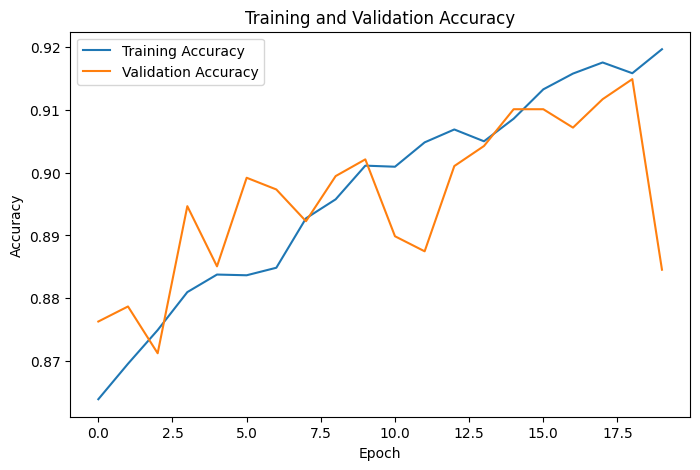

In [34]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

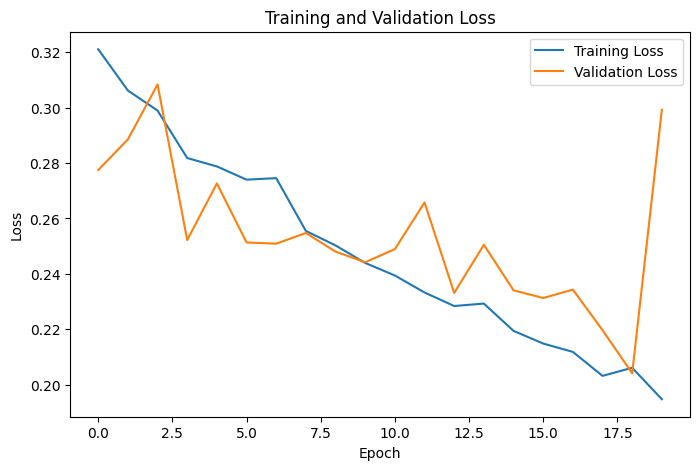

In [35]:
# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 9- Classification Metrics

Precision

Recall

F1-score

In [36]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print(classification_report(y_true, y_pred, target_names=['Cat', 'Dog']))

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step
Precision: 0.9199785177228786
Recall: 0.9136
F1-score: 0.9167781643029168
              precision    recall  f1-score   support

         Cat       0.91      0.92      0.92      1875
         Dog       0.92      0.91      0.92      1875

    accuracy                           0.92      3750
   macro avg       0.92      0.92      0.92      3750
weighted avg       0.92      0.92      0.92      3750



# 10- Create the Confusion Matrix

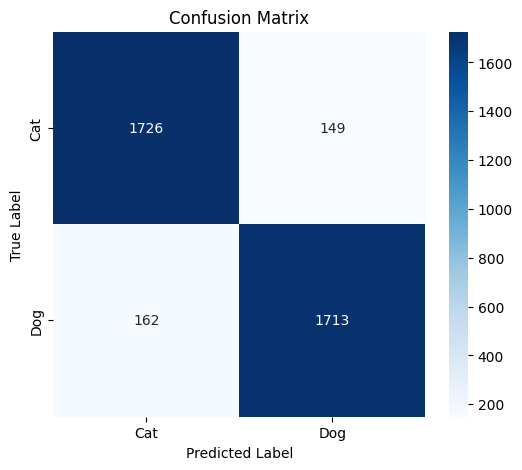

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'],
            yticklabels=['Cat', 'Dog'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 11- Findings and Observations

Accuracy: 0.8536

Loss: 0.3572

Observations:
- The CNN model achieved good performance on the cats vs dogs classification task.
- The model reached an accuracy of 85.36%, which indicates that it learned useful visual features from the dataset.
- Data preprocessing and augmentation helped improve generalization.
- The model may still be improved further by increasing the number of epochs, tuning hyperparameters, or using a deeper CNN architecture.
- Additional evaluation metrics such as precision, recall, F1-score, and the confusion matrix provided a more complete understanding of the model performance.

Accuracy: 0.9171

Loss: 0.2122

Observations:

* The improved CNN model achieved strong performance on the cats vs. dogs classification task.

* Increasing the number of epochs and applying EarlyStopping significantly improved the model’s performance.

* The previous model achieved 85.36% accuracy with a test loss of 0.3573.

* The updated model achieved 91.71% accuracy with a test loss of 0.2122.

* Allowing the model to train longer while stopping automatically when validation performance stopped improving helped the model generalize better to unseen test images.

* The lower loss value indicates that the model’s predictions became more confident and accurate.

* Data preprocessing, data augmentation, and the improved training strategy contributed to better overall model performance.

* Additional evaluation metrics such as precision, recall, F1-score, and the confusion matrix provided a more comprehensive understanding of the model’s classification performance.